# Final Project: Topic Modeling
**Problem Statement:**

You are to develop your own use case for topic modeling. The use case should involve text data that interests you and should be realistic for a data scientist or machine learning developer. 

In [1]:
import pandas as pd # data manipulation
import langdetect  # language detection
import matplotlib.pyplot  # plotting
import nltk  # natural language processing
import numpy  # arrays and matrices
import pandas  # dataframes
import pyLDAvis  # plotting
import pyLDAvis.lda_model  # plotting
import regex  # regular expressions
import sklearn  # machine learning
import unicodedata  # unicode data manipulation
import random # random number generation

# Text preprocessing and feature extraction
from sklearn.decomposition import NMF  # NMF model
from sklearn.decomposition import LatentDirichletAllocation  # LDA model
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF vectorizer
from nltk.stem import WordNetLemmatizer  # lemmatizer
from sklearn.feature_extraction.text import CountVectorizer  # Count vectorizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hunter\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hunter\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Hunter\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/tripadvisor_hotel_reviews.csv"
df = pd.read_csv(url)
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Executive Summary: In 180 to 200 words, provide an overview of the notebooks you developed. Describe the use case, data, preprocessing steps, model development, and main points of the analysis. State which model works best or that none of the models were satisfactory and provide reasons. Describe the topics and explain how the model will address the use case, or if none of the models worked well, state what the next steps should be.

Preprocessing: Clean and prepare text for LDA and NMF topic modeling. Include steps such as case normalization, lemmatization, stop word removal, and tokenization. 

c:\Users\Hunter\anaconda3\envs\neural_3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hunter\anaconda3\envs\neural_3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hunter\anaconda3\envs\neural_3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


<AxesSubplot:xlabel='Rating', ylabel='count'>

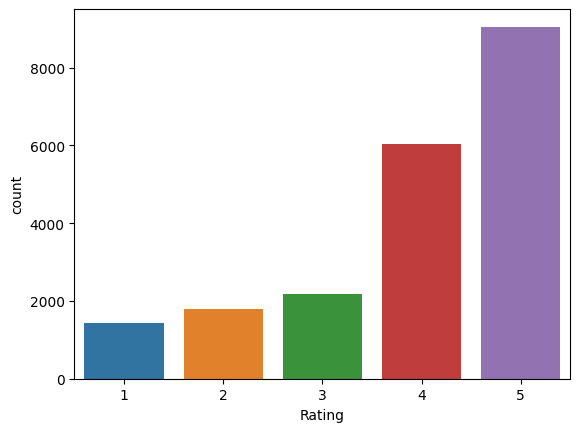

In [3]:
import seaborn as sns

sns.countplot(x='Rating', data=df)

### Language Filter

In [4]:
def do_language_identifying(txt):
    try: the_language = langdetect.detect(txt)
    except: the_language = 'none'
    return the_language

df['Language'] = df['Review'].apply(do_language_identifying)
df['Language'].value_counts()

Language
en    20469
fr       10
af        6
ca        2
ro        2
es        1
nl        1
Name: count, dtype: int64

Removing non-english reviews

In [5]:
reviews_en = df[df['Language'] == 'en']

### Tokenization / Removing Punctuation / Case Normalization

In [6]:
WORD_RE = regex.compile(r"(?V1)\p{L}+(?:[’'-]\p{L}+)*")

def tokenize_for_topics(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = regex.sub(r"[‘’`´]", "'", text)      # normalize apostrophes
    text = regex.sub(r"[‐‑‒–—−]", "-", text)    # normalize dash variants
    return WORD_RE.findall(text)

reviews_en["Tokens"] = reviews_en["Review"].apply(tokenize_for_topics)

reviews_en['Tokens'][0]

C:\Users\Hunter\AppData\Local\Temp\ipykernel_30560\4241627905.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_en["Tokens"] = reviews_en["Review"].apply(tokenize_for_topics)


['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'reviews',
 'did',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'non-existent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillows',
 'not',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bangs',
 'doors',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'just',
 'noisy',
 'neighbors',
 'aveda',
 'bath',
 'products',
 'nice',
 'did',
 'not',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'having',
 'pay',
 'parking',
 'night']

### Removing Stop Words

In [7]:
list_stop_words = nltk.corpus.stopwords.words("English")
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [token for token in tokens if token not in list_stop_words])

C:\Users\Hunter\AppData\Local\Temp\ipykernel_30560\2692143640.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [token for token in tokens if token not in list_stop_words])


### Lemmatization

In [8]:
lemmatizer = WordNetLemmatizer()
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

C:\Users\Hunter\AppData\Local\Temp\ipykernel_30560\1502571546.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])


In [9]:
reviews_en['Tokens'].head()

0    [nice, hotel, expensive, parking, got, good, d...
1    [ok, nothing, special, charge, diamond, member...
2    [nice, room, experience, hotel, monaco, seattl...
3    [unique, great, stay, wonderful, time, hotel, ...
4    [great, stay, great, stay, went, seahawk, game...
Name: Tokens, dtype: object

Models: Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Vectorizing the text data: LDA
### Hyperparameter Stack:
.....

In [10]:
LDA_data = reviews_en.copy()
LDA_data['clean_text'] = LDA_data['Tokens'].apply(lambda tokens: ' '.join(tokens))
LDA_data[['Tokens', 'clean_text']].head()

,Tokens,clean_text
0,"[nice, hotel, expensive, parking, got, good, d...",nice hotel expensive parking got good deal sta...
1,"[ok, nothing, special, charge, diamond, member...",ok nothing special charge diamond member hilto...
2,"[nice, room, experience, hotel, monaco, seattl...",nice room experience hotel monaco seattle good...
3,"[unique, great, stay, wonderful, time, hotel, ...",unique great stay wonderful time hotel monaco ...
4,"[great, stay, great, stay, went, seahawk, game...",great stay great stay went seahawk game awesom...


In [12]:
LDA_data = reviews_en.copy()
LDA_data['clean_text'] = LDA_data['Tokens'].apply(lambda tokens: ' '.join(tokens))
LDA_data[['Tokens', 'clean_text']].head()

,Tokens,clean_text
0,"[nice, hotel, expensive, parking, got, good, d...",nice hotel expensive parking got good deal sta...
1,"[ok, nothing, special, charge, diamond, member...",ok nothing special charge diamond member hilto...
2,"[nice, room, experience, hotel, monaco, seattl...",nice room experience hotel monaco seattle good...
3,"[unique, great, stay, wonderful, time, hotel, ...",unique great stay wonderful time hotel monaco ...
4,"[great, stay, great, stay, went, seahawk, game...",great stay great stay went seahawk game awesom...


In [13]:
hotel_stop_words = ['hotel', 'room', 'stay', 'really', 'just', 'got', 'went', 'also', 'said', 'told', 'day', 'night', 'time', 'week', 'year',    'place', 'thing', 'way', 'bit', 'lot', 'little', 'came', 'come', 'went', 'going', 'went', 'away', 'check', 'booked', 'booking', 'trip', 'visit', 'stayed', 'rooms', 'hotels', 'stays']
cv_hw = CountVectorizer(
    max_df=0.85,        
    min_df=5,           
    max_features=2000,
    #stop_words= hotel_stop_words
)
 
dtm_cv_hw = cv_hw.fit_transform(LDA_data['clean_text'])

In [14]:
lda_model_hw_1 = LatentDirichletAllocation(n_components=5,
                                        max_iter=10,
                                        doc_topic_prior = 0.1,
                                        topic_word_prior = 0.01,
                                        random_state=42)

lda_model_hw_2 = LatentDirichletAllocation(n_components=5,
                                        max_iter=15,
                                        doc_topic_prior = 0.2,
                                        topic_word_prior = 0.2,
                                        random_state=42)

lda_model_hw_1.fit(dtm_cv_hw)
lda_model_hw_2.fit(dtm_cv_hw)

LatentDirichletAllocation(doc_topic_prior=0.2, max_iter=15, n_components=5,
                          random_state=42, topic_word_prior=0.2)

In [38]:
models = [lda_model_hw_1, lda_model_hw_2]
feature_names = cv_hw.get_feature_names_out()

for model_num, model in enumerate(models):
    print(f"=== Model {model_num + 1} ===")
    for index, topic in enumerate(model.components_):
        print(f'THE TOP 10 WORDS FOR TOPIC #{index}')
        
        top_word_indices = topic.argsort()[-10:]
        
        top_words = [feature_names[idx] for idx in top_word_indices]
        print(top_words)
        print('\n')

=== Model 1 ===
THE TOP 10 WORDS FOR TOPIC #0
['people', 'pool', 'great', 'time', 'good', 'day', 'room', 'food', 'beach', 'resort']


THE TOP 10 WORDS FOR TOPIC #1
['bed', 'place', 'night', 'location', 'good', 'stay', 'nice', 'great', 'room', 'hotel']


THE TOP 10 WORDS FOR TOPIC #2
['night', 'clean', 'stay', 'breakfast', 'good', 'staff', 'location', 'great', 'room', 'hotel']


THE TOP 10 WORDS FOR TOPIC #3
['bed', 'desk', 'time', 'day', 'staff', 'service', 'night', 'stay', 'hotel', 'room']


THE TOP 10 WORDS FOR TOPIC #4
['beautiful', 'food', 'restaurant', 'service', 'room', 'staff', 'beach', 'great', 'hotel', 'pool']


=== Model 2 ===
THE TOP 10 WORDS FOR TOPIC #0
['people', 'great', 'pool', 'time', 'room', 'day', 'good', 'food', 'beach', 'resort']


THE TOP 10 WORDS FOR TOPIC #1
['place', 'bed', 'night', 'good', 'location', 'stay', 'nice', 'great', 'room', 'hotel']


THE TOP 10 WORDS FOR TOPIC #2
['night', 'clean', 'stay', 'breakfast', 'staff', 'good', 'location', 'great', 'room', '

In [39]:
for model_num, model in enumerate(models):
    # Generate topic probabilities
    topic_results = model.transform(dtm_cv_hw)

    # Assign topic index to a copy so each model's results are preserved
    temp_df = LDA_data.copy()
    temp_df['Topic'] = topic_results.argmax(axis=1)

    # Reorder columns
    temp_df = temp_df[['Review', 'Rating', 'Topic', 'Tokens']]

    # Preview results
    print(f"=== Model {model_num + 1} Document-Topic Table ===")
    display(temp_df.head())

=== Model 1 Document-Topic Table ===


,Review,Rating,Topic,Tokens
0,nice hotel expensive parking got good deal sta...,4,1,"[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,3,"[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,3,"[nice, room, experience, hotel, monaco, seattl..."
3,"unique, great stay, wonderful time hotel monac...",5,1,"[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,3,"[great, stay, great, stay, went, seahawk, game..."


=== Model 2 Document-Topic Table ===


,Review,Rating,Topic,Tokens
0,nice hotel expensive parking got good deal sta...,4,1,"[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,3,"[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,3,"[nice, room, experience, hotel, monaco, seattl..."
3,"unique, great stay, wonderful time hotel monac...",5,1,"[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,3,"[great, stay, great, stay, went, seahawk, game..."


In [40]:
for model_num, model in enumerate(models):
    temp_df = LDA_data.copy()
    temp_df['Topic'] = model.transform(dtm_cv_hw).argmax(axis=1)

    print(f"=== Model {model_num + 1} ===")
    print(f"Perplexity: {model.perplexity(dtm_cv_hw):.4f}")
    print()
    print(temp_df.groupby('Topic')['Rating'].mean())
    print()
    print(temp_df['Topic'].value_counts())
    print('\n')

=== Model 1 ===
Perplexity: 733.0285

Topic
0    3.734473
1    4.059662
2    4.404663
3    2.535671
4    4.596672
Name: Rating, dtype: float64

Topic
2    7935
1    4140
3    3308
0    3043
4    2043
Name: count, dtype: int64


=== Model 2 ===
Perplexity: 725.4745

Topic
0    3.748957
1    4.091014
2    4.381577
3    2.393764
4    4.660502
Name: Rating, dtype: float64

Topic
2    7621
1    4351
0    3115
3    3111
4    2271
Name: count, dtype: int64




### Vectorization for NMF
### Hyperparameter Stack:
.....

In [17]:
# Create a dedicated NMF dataframe from your english reviews
nmf_data = reviews_en.copy()

# Ensure the clean_text column exists (joining the lemmatized tokens)
nmf_data['clean_text'] = nmf_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Preview the clean data
nmf_data[['Review', 'clean_text']].head()

,Review,clean_text
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [ ]:
def nmf_reconstruction_error(data, ntopics, max_df, min_df, max_features):  # function to calculate reconstruction error for NMF model with different numbers of topics and vectorizer parameters
    nmf_output_dict = {
        "Number Of Topics": [], 
        "Reconstruction Error": []
    }
    
    for t in ntopics:   # iterate over the list of topic numbers
        nmf = sklearn.decomposition.NMF(
            n_components=t,
            solver='cd',
            random_state=0
        )
        nmf.fit(data)
        
        nmf_output_dict["Number Of Topics"].append(t)
        nmf_output_dict["Reconstruction Error"].append(nmf.reconstruction_err_)
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated reconstruction error for {t} topics: {nmf_output_dict['Reconstruction Error'][-1]}")
        
    output_df = pandas.DataFrame(nmf_output_dict)   # convert the output dictionary to a pandas dataframe for easier analysis
    
    index_min_perplexity = output_df["Reconstruction Error"].idxmin()   # get the index of the minimum reconstruction error
    output_num_topics = output_df.loc[
        index_min_perplexity,
        "Number Of Topics"
    ]
        
    return (output_df, output_num_topics)

In [ ]:


tfidf_number_features = 2000
tfidf_number_docs = 10
tfidf_number_words = 10

tfidf_max_dfs = [0.85]
tfidf_min_dfs = [2, 5, 10]
tfidf_max_feats = [1000, 2000]

tfidf_vectorizers = [] 
for max_df in tfidf_max_dfs:
    for min_df in tfidf_min_dfs:
        for max_features in tfidf_max_feats:
            tfidf_vectorizer = TfidfVectorizer(
                max_df=max_df,
                min_df=min_df,
                max_features=max_features
            )
            tfidf_vectorizers.append(tfidf_vectorizer)

In [23]:
import warnings
warnings.filterwarnings("ignore")
tfidf_perplexity_dfs = []
for tfidf_v in tfidf_vectorizers:
    dtm_cv = tfidf_v.fit_transform(nmf_data['clean_text'])

    nmf_perplexity, optimal_num_topics = nmf_reconstruction_error(
        dtm_cv,
        [3, 4, 5, 6],
        tfidf_v.max_df,
        tfidf_v.min_df,
        tfidf_v.max_features
    )

    nmf_perplexity['Max_Features'] = tfidf_v.max_features
    nmf_perplexity['Max_DF'] = tfidf_v.max_df
    nmf_perplexity['Min_DF'] = tfidf_v.min_df
    tfidf_perplexity_dfs.append(nmf_perplexity)

max_df = 0.85, min_df = 2, max_features = 1000 : Calculated reconstruction error for 3 topics: 134.30150954126043
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated reconstruction error for 4 topics: 133.85652012906516
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated reconstruction error for 5 topics: 133.4215637047609
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated reconstruction error for 6 topics: 133.08783106052599
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 3 topics: 136.13422942107556
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 4 topics: 135.78303277519308
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 5 topics: 135.44926669769637
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 6 topics: 135.18654199243275
max_df = 0.85, min_df = 5, max_features = 1000 : Calculated reconstruction error for 3 to

In [ ]:
def plot_tsne(data, threshold):
    # filter data according to threshold
    index_meet_threshold = numpy.amax(data, axis=1) >= threshold    # get boolean index of rows where max topic probability meets threshold
    lda_transform_filt = data[index_meet_threshold]
    
    # fit tsne model
    # x-d -> 2-d, x = number of topics
    tsne = sklearn.manifold.TSNE(   # create TSNE model with specified parameters
        n_components=2, 
        verbose=0, 
        random_state=0, 
        angle=0.5, 
        init='pca'
    )
    tsne_fit = tsne.fit_transform(lda_transform_filt)   # fit and transform the filtered data using the TSNE model
    
    # most probable topic for each headline
    most_prob_topic = []
    for i in range(tsne_fit.shape[0]):  # iterate over each row in the filtered data
        most_prob_topic.append(lda_transform_filt[i].argmax())  # append the index of the maximum topic probability for each row to the most_prob_topic list
    
    print("LENGTH:\n{}\n".format(len(most_prob_topic))) # print the length of the most_prob_topic list to verify it matches the number of rows in the filtered data

    unique, counts = numpy.unique(  # get unique topic indices and their counts
        numpy.array(most_prob_topic), 
        return_counts=True
    )

    print("COUNTS:\n{}\n".format(numpy.asarray((unique, counts)).T))    # print the unique topic indices and their counts in a readable format
    
    # make plot
    color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

    for i in list(set(most_prob_topic)):    # iterate over unique topic indices
        indices = [idx for idx, val in enumerate(most_prob_topic) if val == i]# get indices of rows where the most probable topic matches the current topic index
        matplotlib.pyplot.scatter(
            x=tsne_fit[indices, 0], 
            y=tsne_fit[indices, 1], 
            s=0.5, 
            c=color_list[i], 
            label='Topic' + str(i),
            alpha=0.25
        )

    matplotlib.pyplot.xlabel('x-tsne')
    matplotlib.pyplot.ylabel('y-tsne')
    matplotlib.pyplot.legend(markerscale=10)

In [43]:
print(len(tfidf_vectorizers))


6


LENGTH:
20469

COUNTS:
[[   0 4281]
 [   1 4171]
 [   2 6383]
 [   3 5634]]



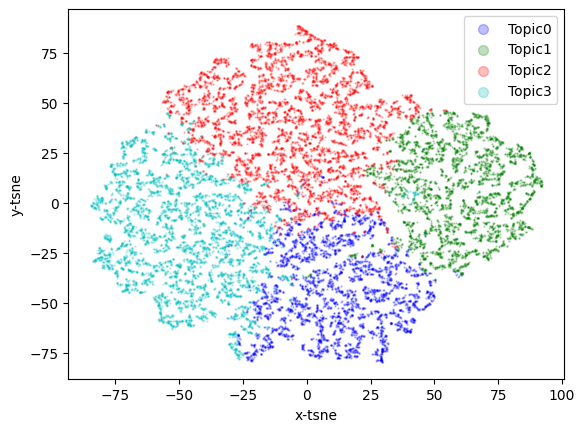

In [50]:

nmf = sklearn.decomposition.NMF(
    n_components=4,
    solver='cd',
    random_state=0
)

nmf_transformed = nmf.fit_transform(tfidf_vectorizers[4].fit_transform(nmf_data['clean_text']))

plot_tsne(data=nmf_transformed, threshold=0)


In [ ]:

def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_ # shape: (n_topics, n_words)
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]    # normalize rows to sum to 1
    # topic to document matrix
    H = mod.transform(vec)  # shape: (n_docs, n_topics)
    
    W_dict = {}
    H_dict = {}
    
    for tpc_idx, tpc_val in enumerate(W_norm):  # iterate over topics
        topic = "Topic{}".format(tpc_idx)   # create topic name
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]    # get indices of top n words for this topic
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]   # create list of tuples (value, word) for top n words
        W_dict[topic] = W_names_values  # assign list of tuples to topic in W_dict
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]   # get indices of top n documents for this topic
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j])   # create list of tuples (value, document) for top n documents
            for j in H_indices
        ]
        H_dict[topic] = H_names_values  # assign list of tuples to topic in H_dict
        
    W_df = pandas.DataFrame(    # create dataframe from W_dict with word names as index
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )']'
    ''
    H_df = pandas.DataFrame(    # create dataframe from H_dict with document names as index
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
        
    return (W_df, H_df)

In [ ]:
wdf, hdf, = get_topics(
    mod=nmf, 
    vec=tfidf_vectorizers[0].fit_transform(nmf_data['clean_text']), # fit_transform the clean text data using the first TF-IDF vectorizer
    names=tfidf_vectorizers[0].get_feature_names_out(), 
    docs=nmf_data['Review'].tolist(), 
    ndocs=tfidf_number_docs, 
    nwords=tfidf_number_words
)

In [36]:
print(wdf)

                    Topic0                Topic1             Topic2  \
Word0      (0.0444, great)      (0.0219, resort)     (0.0257, room)   
Word1      (0.0356, hotel)         (0.02, beach)      (0.0091, bed)   
Word2   (0.0236, location)        (0.0128, food)    (0.0088, night)   
Word3       (0.0231, stay)        (0.0124, pool)    (0.0085, hotel)   
Word4      (0.0226, staff)         (0.0083, day)    (0.0077, floor)   
Word5   (0.0153, friendly)        (0.0082, time)     (0.0072, desk)   
Word6    (0.0149, helpful)      (0.0079, people)      (0.007, stay)   
Word7     (0.0138, stayed)        (0.0076, good)  (0.0062, service)   
Word8   (0.013, wonderful)  (0.0074, restaurant)      (0.0061, day)   
Word9  (0.0116, excellent)        (0.007, drink)     (0.006, check)   

                    Topic3  
Word0      (0.0303, hotel)  
Word1       (0.0226, good)  
Word2       (0.0139, walk)  
Word3  (0.0132, breakfast)  
Word4    (0.0116, station)  
Word5       (0.0104, nice)  
Word6     (0.01